In [7]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import yaml
import cv2
import matplotlib.pyplot as plt
import torch

from ultralytics import YOLO

In [4]:
PROJECT_ROOT = Path.cwd().parent

METADATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "image_metadata.csv"
)

YOLO_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "yolo_plate_detection"
)

yaml_path = YOLO_DIR / "data.yaml"

images = pd.read_csv(METADATA_PATH)

images.head()

,split,track_id,frame_number,image_name,image_path,annotation_path,image_width,image_height,camera,vehicle_type,...,plate_brightness,plate_contrast,plate_blur_score,corners_valid,plate_box_valid,vehicle_box_valid,plate_inside_vehicle,character_count_matches,character_boxes_valid,annotation_valid
0,training,track0001,1,track0001[01].png,data/raw/ufpr_alpr/training/track0001/track000...,data/raw/ufpr_alpr/training/track0001/track000...,1920,1080,GoPro Hero4 Silver,car,...,126.248095,38.710966,2236.944449,True,True,True,True,True,True,True
1,training,track0001,2,track0001[02].png,data/raw/ufpr_alpr/training/track0001/track000...,data/raw/ufpr_alpr/training/track0001/track000...,1920,1080,GoPro Hero4 Silver,car,...,125.889396,37.965550,2143.694193,True,True,True,True,True,True,True
2,training,track0001,3,track0001[03].png,data/raw/ufpr_alpr/training/track0001/track000...,data/raw/ufpr_alpr/training/track0001/track000...,1920,1080,GoPro Hero4 Silver,car,...,124.343629,36.829864,1958.690337,True,True,True,True,True,True,True
3,training,track0001,4,track0001[04].png,data/raw/ufpr_alpr/training/track0001/track000...,data/raw/ufpr_alpr/training/track0001/track000...,1920,1080,GoPro Hero4 Silver,car,...,121.887827,37.349510,2167.056821,True,True,True,True,True,True,True
4,training,track0001,5,track0001[05].png,data/raw/ufpr_alpr/training/track0001/track000...,data/raw/ufpr_alpr/training/track0001/track000...,1920,1080,GoPro Hero4 Silver,car,...,121.563492,38.328790,1943.057892,True,True,True,True,True,True,True


In [7]:
# YOLO cannot directly train from a CSV. Instead, convert each image with images and labels where each label file contains
# class x_center y_center width height normalized between 0 and 1.
def convert_row_to_yolo(row):
    image_width = row["image_width"]
    image_height = row["image_height"]

    xmin = row["plate_xmin"]
    ymin = row["plate_ymin"]
    xmax = row["plate_xmax"]
    ymax = row["plate_ymax"]

    box_width_pixels = xmax - xmin
    box_height_pixels = ymax - ymin

    x_center_pixels = (xmin + xmax) / 2
    y_center_pixels = (ymin + ymax) / 2

    x_center = x_center_pixels / image_width
    y_center = y_center_pixels / image_height
    box_width = box_width_pixels / image_width
    box_height = box_height_pixels / image_height

    class_id = 0

    return (
        class_id,
        x_center,
        y_center,
        box_width,
        box_height,
    )

# Check
sample_row = images.iloc[0]

convert_row_to_yolo(sample_row)

class_id, x_center, y_center, box_width, box_height = (
    convert_row_to_yolo(sample_row)
)

print("Class:", class_id)
print("x center:", x_center)
print("y center:", y_center)
print("width:", box_width)
print("height:", box_height)

Class: 0
x center: 0.4942708333333333
y center: 0.49953703703703706
width: 0.03854166666666667
height: 0.025


In [11]:
# Copy image and create label files
split_map = {
    "training": "train",
    "validation": "val",
    "testing": "test",
}

for index, row in images.iterrows():
    source_image_path = PROJECT_ROOT / row["image_path"]

    if not source_image_path.exists():
        raise FileNotFoundError(
            f"Image not found: {source_image_path}"
        )

    yolo_split = split_map[row["split"]]

    destination_image_path = (
        YOLO_DIR
        / "images"
        / yolo_split
        / row["image_name"]
    )

    destination_label_path = (
        YOLO_DIR
        / "labels"
        / yolo_split
        / f"{Path(row['image_name']).stem}.txt"
    )

    shutil.copy2(
        source_image_path,
        destination_image_path,
    )

    (
        class_id,
        x_center,
        y_center,
        box_width,
        box_height,
    ) = convert_row_to_yolo(row)

    label_line = (
        f"{class_id} "
        f"{x_center:.8f} "
        f"{y_center:.8f} "
        f"{box_width:.8f} "
        f"{box_height:.8f}\n"
    )

    destination_label_path.write_text(
        label_line,
        encoding="utf-8",
    )

print("YOLO dataset created.")

YOLO dataset created.


In [18]:
# Validate image and label counts
for split in ["train", "val", "test"]:
    image_count = len(
        list((YOLO_DIR / "images" / split).glob("*.png"))
    )

    label_count = len(
        list((YOLO_DIR / "labels" / split).glob("*.txt"))
    )

    print(
        f"{split}: "
        f"{image_count} images, "
        f"{label_count} labels"
    )

# Validate all label values
validation_errors = []

for split in ["train", "val", "test"]:
    label_paths = (
        YOLO_DIR
        / "labels"
        / split
    ).glob("*.txt")

    for label_path in label_paths:
        lines = label_path.read_text().strip().splitlines()

        if len(lines) != 1:
            validation_errors.append(
                {
                    "label_path": str(label_path),
                    "error": f"Expected 1 line, found {len(lines)}",
                }
            )
            continue

        values = lines[0].split()

        if len(values) != 5:
            validation_errors.append(
                {
                    "label_path": str(label_path),
                    "error": f"Expected 5 values, found {len(values)}",
                }
            )
            continue

        class_id = int(values[0])
        coordinates = np.array(
            [float(value) for value in values[1:]]
        )

        if class_id != 0:
            validation_errors.append(
                {
                    "label_path": str(label_path),
                    "error": f"Unexpected class ID: {class_id}",
                }
            )

        if not np.all(
            (coordinates >= 0)
            & (coordinates <= 1)
        ):
            validation_errors.append(
                {
                    "label_path": str(label_path),
                    "error": f"Coordinates outside range: {coordinates}",
                }
            )

        if coordinates[2] <= 0 or coordinates[3] <= 0:
            validation_errors.append(
                {
                    "label_path": str(label_path),
                    "error": "Width or height is not positive",
                }
            )

validation_errors = pd.DataFrame(validation_errors)

print("Validation errors:", len(validation_errors))

if not validation_errors.empty:
    display(validation_errors.head())

train: 1800 images, 1800 labels
val: 900 images, 900 labels
test: 1800 images, 1800 labels
Validation errors: 0


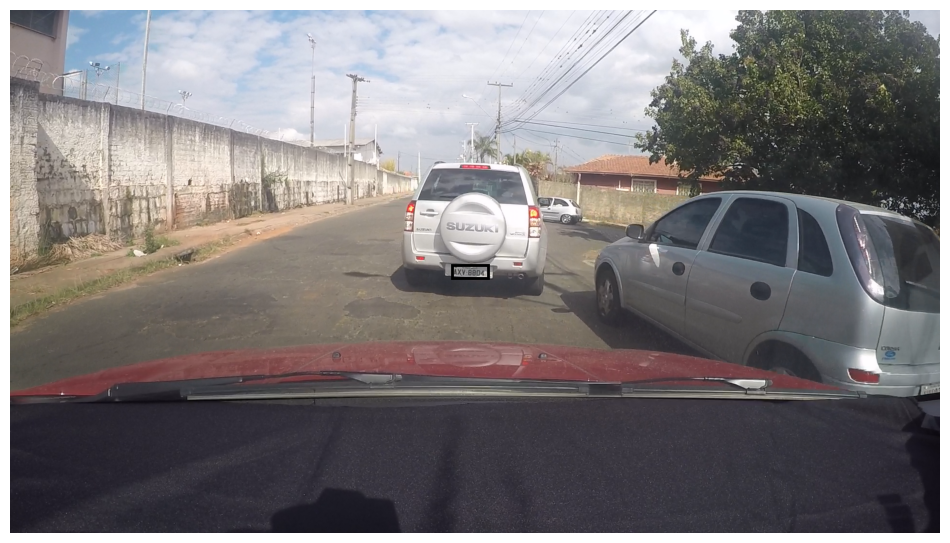

In [19]:
# Validate the bounding box
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def display_yolo_annotation(
    image_path,
    label_path,
):
    image = cv2.imread(str(image_path))

    if image is None:
        raise FileNotFoundError(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB,
    )

    image_height, image_width = image.shape[:2]

    label_values = (
        Path(label_path)
        .read_text()
        .strip()
        .split()
    )

    _, x_center, y_center, box_width, box_height = map(
        float,
        label_values,
    )

    box_width_pixels = box_width * image_width
    box_height_pixels = box_height * image_height

    xmin = (
        x_center * image_width
        - box_width_pixels / 2
    )

    ymin = (
        y_center * image_height
        - box_height_pixels / 2
    )

    fig, ax = plt.subplots(figsize=(12, 7))

    ax.imshow(image)

    rectangle = Rectangle(
        (xmin, ymin),
        box_width_pixels,
        box_height_pixels,
        fill=False,
        linewidth=2,
    )

    ax.add_patch(rectangle)
    ax.axis("off")

    plt.show()

sample_image = (
    YOLO_DIR
    / "images"
    / "train"
    / "track0001[01].png"
)

sample_label = (
    YOLO_DIR
    / "labels"
    / "train"
    / "track0001[01].txt"
)

display_yolo_annotation(
    sample_image,
    sample_label,
)

In [8]:
DEVICE = 0 if torch.cuda.is_available() else "cpu"

In [ ]:
# Train model
MODEL_NAME = "yolo26n.pt"
RUN_NAME = "yolo26n_640_baseline"

EPOCHS = 50
IMAGE_SIZE = 640
BATCH_SIZE = 8
PATIENCE = 10

model = YOLO(MODEL_NAME)

train_results = model.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    device=DEVICE,
    workers=0,
    seed=42,
    deterministic=True,
    project=str(PROJECT_ROOT / "runs" / "detect"),
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
)

Ultralytics 8.4.104  Python-3.14.6 torch-2.13.0+cpu CPU (12th Gen Intel Core i7-1280P)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\mingj\OneDrive\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi

In [24]:
# Choose best checkpoint
RUN_DIR = (
    PROJECT_ROOT
    / "runs"
    / "detect"
    / RUN_NAME
)

BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"

print(BEST_WEIGHTS)
print(BEST_WEIGHTS.exists())

best_model = YOLO(str(BEST_WEIGHTS))

# Validate on best checkpoint
validation_results = best_model.val(
    data=str(yaml_path),
    split="val",
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=0,
    project=str(PROJECT_ROOT / "runs" / "detect"),
    name=f"{RUN_NAME}_validation",
)

validation_results.results_dict

c:\Users\mingj\OneDrive\Desktop\Plate-Recognition\runs\detect\yolo26n_640_baseline\weights\best.pt
True
Ultralytics 8.4.104  Python-3.14.6 torch-2.13.0+cpu CPU (12th Gen Intel Core i7-1280P)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.30.0 ms, read: 167.722.0 MB/s, size: 1968.6 KB)
val: Scanning C:\Users\mingj\OneDrive\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\labels\val.cache... 900 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 900/900 222.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 113/113 1.4it/s 1:220.7ss
                   all        900        900      0.961      0.975      0.992      0.737
Speed: 0.8ms preprocess, 28.8ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\mingj\OneDrive\Desktop\Plate-Recognition\runs\detect\yolo26n_640_baseline_validation


{'metrics/precision(B)': 0.9605805248075164,
 'metrics/recall(B)': 0.9747270834082078,
 'metrics/mAP50(B)': 0.9922131165602648,
 'metrics/mAP50-95(B)': 0.7373708074596326,
 'fitness': 0.7373708074596326}

In [25]:
# Validate on best held out test split
test_results = best_model.val(
    data=str(yaml_path),
    split="test",
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=0,
    project=str(PROJECT_ROOT / "runs" / "detect"),
    name=f"{RUN_NAME}_test",
)

test_results.results_dict

Ultralytics 8.4.104  Python-3.14.6 torch-2.13.0+cpu CPU (12th Gen Intel Core i7-1280P)
val: Fast image access  (ping: 0.10.0 ms, read: 161.740.8 MB/s, size: 2194.1 KB)
val: Scanning C:\Users\mingj\OneDrive\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\labels\test... 1800 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1800/1800 174.5it/s 10.3s0.1s
val: New cache created: C:\Users\mingj\OneDrive\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 225/225 1.8it/s 2:090.5ss
                   all       1800       1800      0.971      0.947      0.971      0.754
Speed: 0.8ms preprocess, 27.2ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\mingj\OneDrive\Desktop\Plate-Recognition\runs\detect\yolo26n_640_baseline_test


{'metrics/precision(B)': 0.9714931083867052,
 'metrics/recall(B)': 0.9466454769924705,
 'metrics/mAP50(B)': 0.970897096828331,
 'metrics/mAP50-95(B)': 0.7536173769918297,
 'fitness': 0.7536173769918297}

In [ ]:
# Inspect training history
history = pd.read_csv(RUN_DIR / "results.csv")

history.columns = history.columns.str.strip()

history.head()

,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
0,1,1267.20,1.66775,7.22273,0.00257,0.79001,0.80889,0.88324,0.47014,1.57317,4.33208,0.00328,0.000664,0.000664,0.000664
1,2,1875.85,1.36315,2.98955,0.00176,0.87163,0.85222,0.94470,0.62233,1.16397,2.17166,0.00232,0.001304,0.001304,0.001304
2,3,2474.31,1.22428,1.61011,0.00149,0.84929,0.87556,0.94514,0.61384,1.23081,1.28712,0.00251,0.001918,0.001918,0.001918
3,4,3077.40,1.12320,0.98744,0.00140,0.91265,0.90889,0.97306,0.64300,1.20004,0.85654,0.00237,0.001881,0.001881,0.001881
4,5,3672.53,1.09416,0.72446,0.00134,0.91326,0.94333,0.97858,0.65395,1.17439,0.67327,0.00239,0.001842,0.001842,0.001842


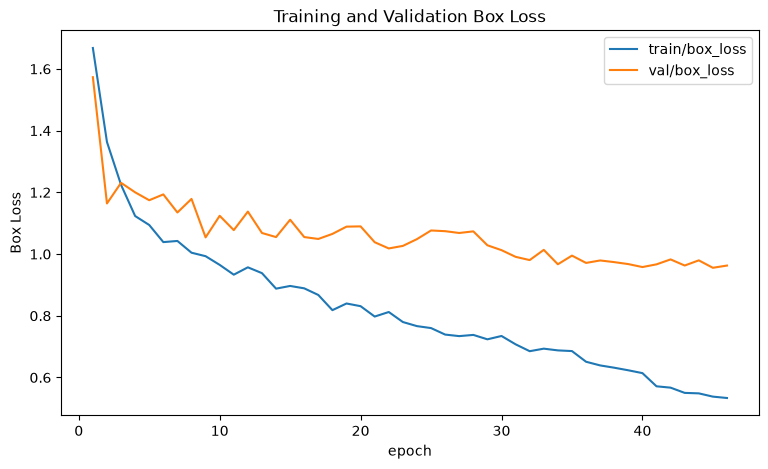

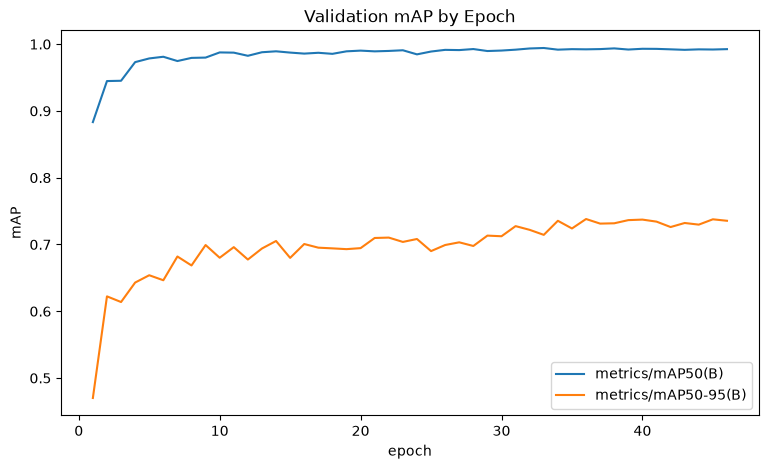

In [ ]:
# Plot losses
history.plot(
    x="epoch",
    y=["train/box_loss", "val/box_loss"],
    figsize=(9, 5),
    title="Training and Validation Box Loss",
)

plt.ylabel("Box Loss")
plt.show()
# Training and Validation loss steadily decreases so model is learning
# However, overfitting as training keeps improving but validation slows down

# Plot validation
history.plot(
    x="epoch",
    y=["metrics/mAP50(B)", "metrics/mAP50-95(B)"],
    figsize=(9, 5),
    title="Validation mAP by Epoch",
)

plt.ylabel("mAP")
plt.show()
# mAP50 is high so finds plates very well (since only needs to match 50%) but mAP50-95 is lower so doesn't localize as well (since needs to match 95%)

## Hypothesis

The EDA showed that license plates occupy on average (`plate_area_ratio`) approximately **0.2%**. This means that the object detection model must find very small objects within high-resolution images.

The baseline YOLO model achieved nearly perfect **mAP@0.50** which shows that it can reliably detect license plates. However, the lower **mAP@0.50:0.95** means that the predicted bounding boxes are not tightly aligned with the actual boxes. In other words, the model successfully **detects** license plates but does not always **localize** them well.

One possible explanation is that the original **1920×1080** images are resized to **640×640** before being passed to the model. License plates are already very small relative to the full image so resizing further reduces the number of pixels representing each plate. Thus, a small localization error of a few pixels can have a large impact on the overall accuracy.

**Hypothesis:** Increasing the input image resolution from **640×640** to **960×960** will provide more pixels to represent each license plate, allowing the detector to predict more accurate bounding boxes. Therefore, we expect **mAP@0.50** to remain approximately the same, while **mAP@0.50:0.95** should improve due to better localization.

## Experiment

### Null hypothesis

Increasing the input resolution from 640×640 to 960×960 does not improve license-plate localization.

### Alternative hypothesis

Increasing the input resolution from 640×640 to 960×960 improves localization because each small license plate is represented by more input pixels.

In [9]:
RUN_NAME_960 = "yolo26n_960"

model_960 = YOLO("yolo26n.pt")

results_960 = model_960.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=960,           # only major experimental change
    batch=8,
    patience=10,
    device=DEVICE,
    workers=0,
    seed=42,
    deterministic=True,
    project=str(PROJECT_ROOT / "runs" / "detect"),
    name=RUN_NAME_960,
    exist_ok=True,
    plots=True,
)

Ultralytics 8.4.104  Python-3.14.6 torch-2.13.0+cpu CPU (12th Gen Intel Core i7-1280P)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\mingj\OneDrive\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi

In [10]:
# Choose best checkpoint
RUNS_DIR = PROJECT_ROOT / "runs" / "detect"

weights_640 = (
    RUNS_DIR
    / "yolo26n_640_baseline"
    / "weights"
    / "best.pt"
)

weights_960 = (
    RUNS_DIR
    / "yolo26n_960"
    / "weights"
    / "best.pt"
)

model_640 = YOLO(str(weights_640))
model_960 = YOLO(str(weights_960))

In [11]:
# Validate on both splits
metrics_640 = model_640.val(
    data=str(yaml_path),
    split="val",
    imgsz=640,
    device=DEVICE,
    workers=0,
)

metrics_960 = model_960.val(
    data=str(yaml_path),
    split="val",
    imgsz=960,
    device=DEVICE,
    workers=0,
)

Ultralytics 8.4.104  Python-3.14.6 torch-2.13.0+cpu CPU (12th Gen Intel Core i7-1280P)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.30.0 ms, read: 175.236.8 MB/s, size: 2082.5 KB)
val: Scanning C:\Users\mingj\OneDrive\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\labels\val.cache... 900 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 900/900 235.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 2.3s/it 2:113.2sss
                   all        900        900      0.961      0.975      0.992      0.737
Speed: 0.6ms preprocess, 51.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to C:\Users\mingj\OneDrive\Desktop\Plate-Recognition\runs\detect\val
Ultralytics 8.4.104  Python-3.14.6 torch-2.13.0+cpu CPU (12th Gen Intel Core i7-1280P)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.

In [ ]:
# Comparison Table
comparison = pd.DataFrame(
    {
        "640": {
            "precision": metrics_640.box.mp,
            "recall": metrics_640.box.mr,
            "mAP50": metrics_640.box.map50,
            "mAP50-95": metrics_640.box.map,
        },
        "960": {
            "precision": metrics_960.box.mp,
            "recall": metrics_960.box.mr,
            "mAP50": metrics_960.box.map50,
            "mAP50-95": metrics_960.box.map,
        },
    }
)

comparison["difference"] = comparison["960"] - comparison["640"]
comparison

# Higher resolution improved localization but slightly decreased precision, recall, and finding plates (mAP50)

,640,960,difference
precision,0.960581,0.942881,-0.017699
recall,0.974727,0.967778,-0.006949
mAP50,0.992213,0.989613,-0.002600
mAP50-95,0.737371,0.780363,0.042992
